Utilice datos históricos desde el 1 de enero de 2020 hasta el 1 de enero de 2023.
1. Análisis de rentabilidad y volatilidad del mercado
• Obtenga datos históricos diarios para la acción de Apple Inc. (ticker: AAPL) desde
Yahoo Finance o cualquier otra fuente financiera disponible.
• Calcule los retornos diarios y realice un análisis exploratorio de dichos retornos
(media, desviación estándar, gráficos de rentabilidad diaria, etc.).
• Determine, mediante un análisis gráfico y estadístico (plots Q-Q, pruebas
estadísticas formales, etc.), qué distribución (Normal o t-Student) se ajusta mejor
a los retornos diarios de Apple. Justifique claramente su elección.
2. Value at Risk (VaR) mediante método Histórico
• Utilizando los retornos históricos diarios de Apple, calcule el VaR al 1% y
horizonte temporal de un día mediante el método histórico.
• Interprete claramente el resultado obtenido, explicando qué representa este
valor en términos de gestión de riesgos.
3. Value at Risk (VaR) mediante método Varianza-Covarianza
• Utilizando nuevamente los retornos históricos diarios de Apple, calcule el VaR al
1% y horizonte temporal de un día mediante el método Varianza-Covarianza.
Justifique las hipótesis estadísticas utilizadas.
• Interprete y compare el resultado obtenido con el método histórico del ejercicio
anterior.
4. Value at Risk (VaR) mediante simulación de Monte Carlo
• Simule mediante el método de Monte Carlo la evolución del precio de la acción
de Apple durante un día.
• Estime el VaR al 1% con horizonte temporal de un día.
• Describa claramente los pasos seguidos para realizar su simulación y explique el
significado del resultado.

# 1. Análisis de rentabilidad y volatilidad del mercado

In [ ]:
df_aapl

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333862,72.394070,71.091169,71.344039,135480400
2020-01-03,71.630669,72.389288,71.406697,71.563236,146322800
2020-01-06,72.201393,72.239927,70.503531,70.753999,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200
...,...,...,...,...,...
2022-12-23,129.659409,130.210060,127.476457,128.735094,63814900
2022-12-27,127.859917,129.216891,126.571782,129.187392,69007800


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

df_aapl = yf.download("AAPL", start="2020-01-01", end="2023-01-01", auto_adjust=False)
print(df_aapl.head())
df_aapl_returns = df_aapl.copy()



df_aapl_returns["pct_returns"] = df_aapl_returns['Adj Close'].pct_change()
df_aapl_returns["log_returns"] = np.log(
    df_aapl_returns['Adj Close'] / df_aapl_returns['Adj Close'].shift(1)
)
df_aapl_returns.dropna(inplace=True)

print(df_aapl_returns.head())

[*********************100%***********************]  1 of 1 completed

Price       Adj Close      Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                                        
2020-01-02  72.333862  75.087502  75.150002  73.797501  74.059998  135480400
2020-01-03  71.630669  74.357498  75.144997  74.125000  74.287498  146322800
2020-01-06  72.201393  74.949997  74.989998  73.187500  73.447502  118387200
2020-01-07  71.861855  74.597504  75.224998  74.370003  74.959999  108872000
2020-01-08  73.017838  75.797501  76.110001  74.290001  74.290001  132079200
Price       Adj Close      Close       High        Low       Open     Volume  \
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL       AAPL   
Date                                                                           
2020-01-03  71.630669  74.357498  75.144997  74.125000  74.287498  146322800   
2020-01-06  72.201393  74.949997  74.989998  73.187500  73.44750

Mean:     0.000753
Std:      0.023255
Skewness: -0.1158
Kurtosis: 4.1346


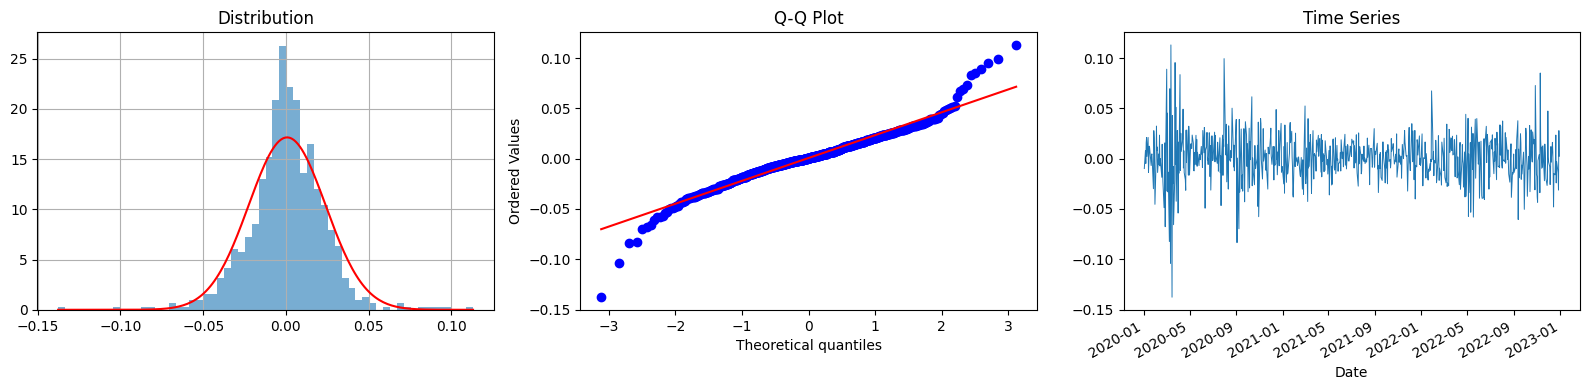

Jarque-Bera:        stat=530.3158, p=0.0000
Shapiro-Wilk:       stat=0.9540, p=0.0000
Kolmogorov-Smirnov: stat=0.0622, p=0.0056


In [ ]:
# Comportamiento de los retornos

s = df_aapl_returns["log_returns"]

print(f"Mean:     {s.mean():.6f}")
print(f"Std:      {s.std():.6f}")
print(f"Skewness: {s.skew():.4f}")
print(f"Kurtosis: {s.kurtosis():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución:
s.hist(bins=60, density=True, alpha=0.6, ax=axes[0])
x = np.linspace(s.min(), s.max(), 200)
axes[0].plot(x, stats.norm.pdf(x, s.mean(), s.std()), 'r-')
axes[0].set_title("Distribution")

# QQ-plot:
stats.probplot(s, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot")

# Evolutivo:
s.plot(ax=axes[2], linewidth=0.7)
axes[2].set_title("Time Series")

plt.tight_layout()
plt.show()

jb_stat, jb_p = stats.jarque_bera(s)
sw_stat, sw_p = stats.shapiro(s.sample(min(len(s), 5000), random_state=42))
ks_stat, ks_p = stats.kstest(s, 'norm', args=(s.mean(), s.std()))

# Sigue una distribución normal?
print(f"Jarque-Bera:        stat={jb_stat:.4f}, p={jb_p:.4f}")
print(f"Shapiro-Wilk:       stat={sw_stat:.4f}, p={sw_p:.4f}")
print(f"Kolmogorov-Smirnov: stat={ks_stat:.4f}, p={ks_p:.4f}")

## T-student vs Normal Distribution

Podemos ver en todos los tests que una t-distrubution se ajusta mejor a los datos:

Desde el histograma, ya podemos percibir colas pesadas, y una  kurtosis muy elevada para una distribución normal. El dato lo confirma: la kurtosis es de 4.13 cuando una normal debería ser de 3, y en el QQ-plot podemos ver esa desviación de la normalidad por el peso de las colas.

Para terminar de asegurarnos, realizamos 3 tests de normalidad: tanto en el test de Jarque-Bera como en el de Shapiro-Wilk y kolgomorov la probabilidad de la hipótesis nula de normalidad es casi 0, por lo que tenemos evidencia suficiente para rechazarla.

De ahora en adelante, trabajaremos con la t-student ya que la assumption de normalidad no es valida.

## Value At Risk

In [ ]:
s = df_aapl_returns["log_returns"]

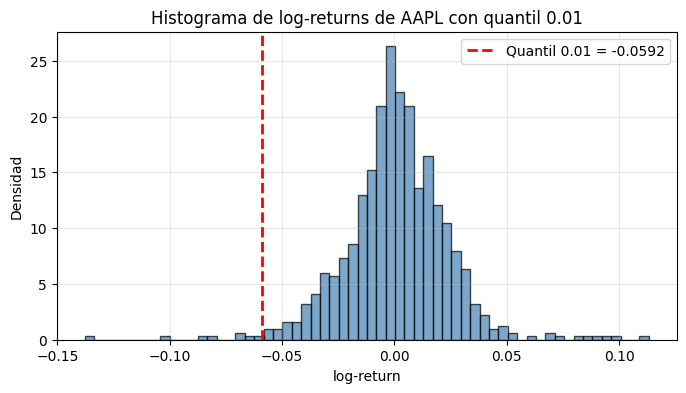

In [ ]:
q01 = s.quantile(0.01)

plt.figure(figsize=(8, 4))
plt.hist(s, bins=60, density=True, alpha=0.7, color='steelblue', edgecolor='k')
plt.axvline(q01, color='red', linestyle='--', linewidth=2, label=f'Quantil 0.01 = {q01:.4f}')
plt.title('Histograma de log-returns de AAPL con quantil 0.01')
plt.xlabel('log-return')
plt.ylabel('Densidad')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Método Histórico

In [ ]:
var_99 = s.quantile(0.01)
print("VaR 99% método histórico:", np.round(var_99,4)*100, "%")

VaR 99% método histórico: -5.92 %


### Método Varianza - Covarianza

In [ ]:
var_vc = stats.norm.ppf(0.01, s.mean(), s.std()) # P(X<x) = 0.01, con X N(mu, std)

print("VaR 99% método varianza-covarianza:", np.round(var_vc,4)*100, "%")

VaR 99% método varianza-covarianza: -5.33 %


### Método de Monte Carlo

In [ ]:
from scipy.stats import t

# Simulamos siguiendo una t-distribución que ya hemos visto que ajusta mejor
df_t, loc_t, scale_t = t.fit(s)

np.random.seed(42)
simulations = t.rvs(df=df_t, loc=loc_t, scale=scale_t, size=100_000)
var_mc_t = np.percentile(simulations, 1)

print("VaR 99% método Monte Carlo con t-Student:", np.round(var_mc_t, 4) * 100, "%")

VaR 99% método Monte Carlo con t-Student: -6.11 %


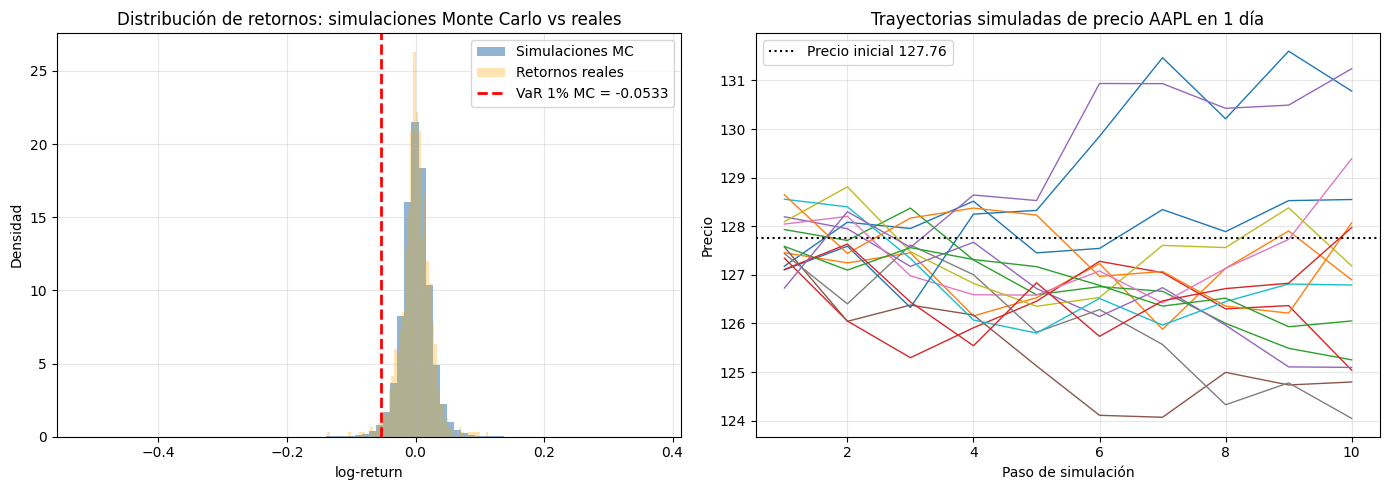

In [ ]:
price0 = df_aapl["Adj Close"].iloc[-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(simulations, bins=80, density=True, alpha=0.6, color='steelblue', label='Simulaciones MC')
axes[0].hist(s, bins=60, density=True, alpha=0.3, color='orange', label='Retornos reales')
axes[0].axvline(var_mc, color='red', linestyle='--', linewidth=2, label=f'VaR 1% MC = {var_mc:.4f}')
axes[0].set_title('Distribución de retornos: simulaciones Monte Carlo vs reales')
axes[0].set_xlabel('log-return')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(alpha=0.3)

n_paths = 15
n_steps = 10
dt = 1 / n_steps
increments = np.random.normal(s.mean() * dt, s.std() * np.sqrt(dt), size=(n_paths, n_steps))
price0 = df_aapl["Adj Close"].iloc[-1].item()  # o float(...)
paths = price0 * np.exp(np.cumsum(increments, axis=1))

for path in paths:
    axes[1].plot(np.arange(1, n_steps + 1), path, linewidth=1)

axes[1].axhline(price0, color='black', linestyle=':', label=f'Precio inicial {price0:.2f}')
axes[1].set_title('Trayectorias simuladas de precio AAPL en 1 día')
axes[1].set_xlabel('Paso de simulación')
axes[1].set_ylabel('Precio')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Método Teoría del Valor Extremo

Umbral seleccionado:   0.0328 (3.28%)
Shape parameter (α):   3.0956
VaR 99% (EVT-Hill):    -0.0604 (6.04%)


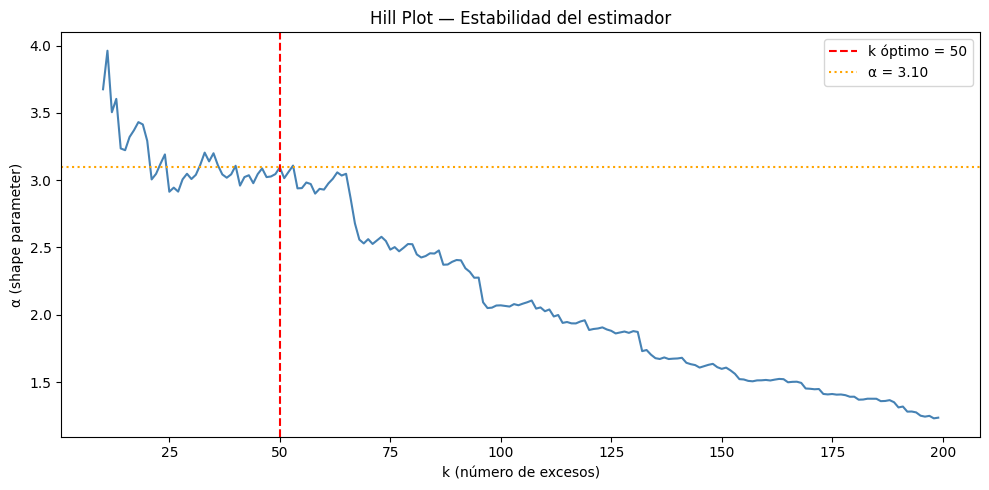

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

losses = -s.values
losses_sorted = np.sort(losses)[::-1]  # descendente

# ── 1. Hill estimator ────────────────────────────────────────────────
def hill_estimator(losses_sorted, k):
    """Shape parameter α para los k excesos superiores."""
    top_k = losses_sorted[:k]
    return 1 / (np.mean(np.log(top_k)) - np.log(top_k[-1]))

# Hill plot: estimamos α para distintos valores de k
k_values = range(10, 200)
hill_alphas = [hill_estimator(losses_sorted, k) for k in k_values]

# ── 2. Umbral: donde Hill estabiliza ────────────────────────────────
k_optimal = 50  # ajusta según donde veas estabilidad en el plot
alpha_hat = hill_estimator(losses_sorted, k_optimal)
threshold = losses_sorted[k_optimal - 1]

print(f"Umbral seleccionado:   {threshold:.4f} ({threshold*100:.2f}%)")
print(f"Shape parameter (α):   {alpha_hat:.4f}")

# ── 3. VaR con EVT ──────────────────────────────────────────────────
n = len(losses)
p = 0.01
var_evt = threshold * (k_optimal / (n * p)) ** (1 / alpha_hat)

print(f"VaR 99% (EVT-Hill):    {-var_evt:.4f} ({var_evt*100:.2f}%)")

# ── 4. Hill plot ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(list(k_values), hill_alphas, color='steelblue', linewidth=1.5)
plt.axvline(k_optimal, color='red', linestyle='--', label=f'k óptimo = {k_optimal}')
plt.axhline(alpha_hat, color='orange', linestyle=':', label=f'α = {alpha_hat:.2f}')
plt.xlabel('k (número de excesos)')
plt.ylabel('α (shape parameter)')
plt.title('Hill Plot — Estabilidad del estimador')
plt.legend()
plt.tight_layout()
plt.show()